In [126]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import warnings

warnings.filterwarnings('ignore')

dt_clf = DecisionTreeClassifier(random_state=2)

iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=42)

dt_clf.fit(X_train, y_train);

In [127]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf, out_file='tree.dot', class_names=iris_data.target_names,
                feature_names=iris_data.feature_names, impurity=True, filled=True)

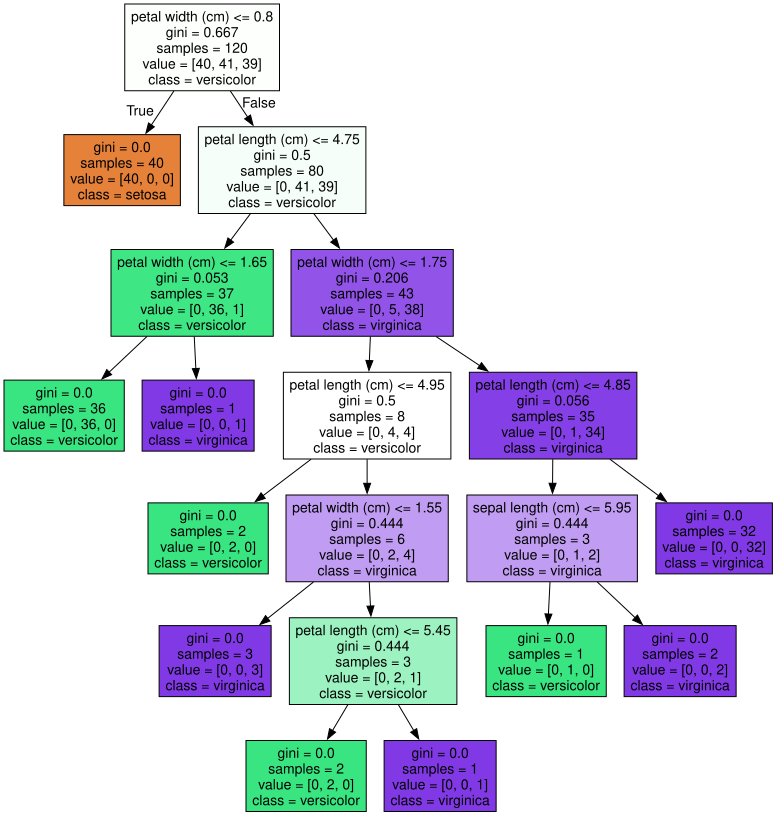

In [128]:
import os
import graphviz

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

with open('./tree.dot') as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

Feature Importance : 
[0.017 0.    0.406 0.577]
sepal length (cm) : 0.016670
sepal width (cm) : 0.000000
petal length (cm) : 0.405935
petal width (cm) : 0.577395


<Axes: >

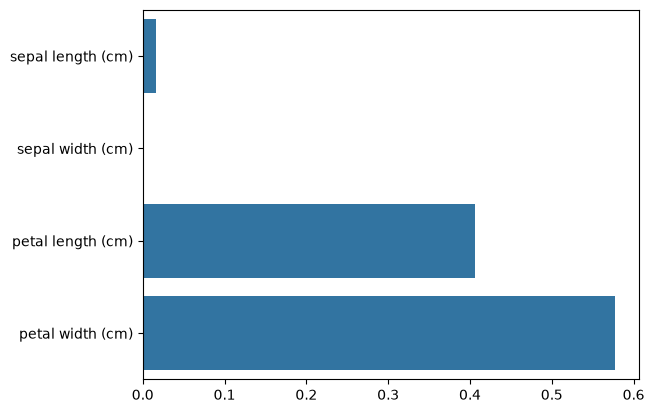

In [129]:
import seaborn as sns
import numpy as np

print("Feature Importance : \n{0}".format(np.round(dt_clf.feature_importances_, 3)))

for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print("{0} : {1:3f}".format(name, value))

sns.barplot(x = dt_clf.feature_importances_, y=iris_data.feature_names)

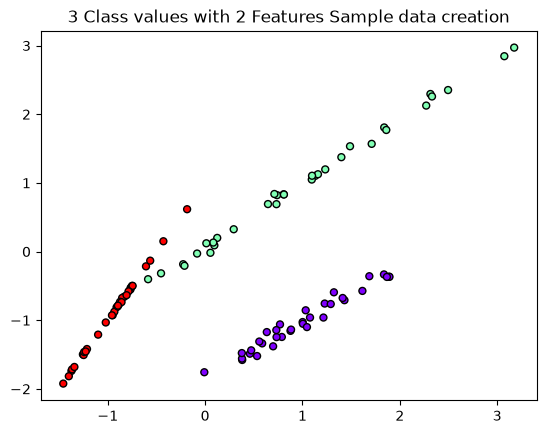

In [130]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

plt.title('3 Class values with 2 Features Sample data creation')

X_features, y_labels = make_classification(n_features = 2, n_redundant=0,
                                           n_informative=2, n_classes=3, n_clusters_per_class=1,
                                           random_state = 42)

plt.scatter(X_features[:, 0], X_features[:, 1], marker='o', c=y_labels,
            s=25, cmap='rainbow', edgecolor='k')

In [131]:
import numpy as np

def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    model.fit(X, y)

    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow', clim=(y.min(), y.max()),
                           zorder=1)

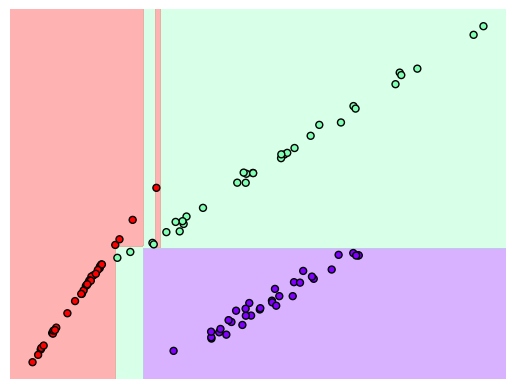

In [132]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

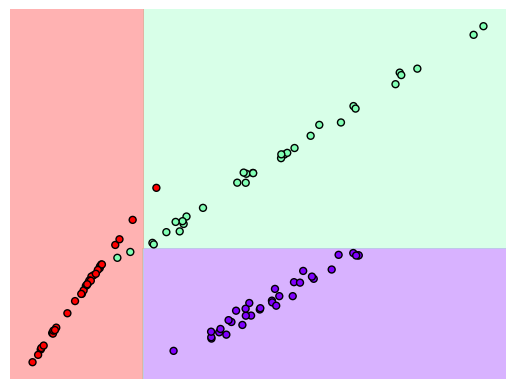

In [133]:
dt_clf = DecisionTreeClassifier(random_state=42, min_samples_leaf=6).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

In [134]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

with open('./data/human_activity_train.csv', encoding='utf-8') as f:
    header = next(csv.reader(f))

feature_name_org = header[:-2]
feature_name_df = pd.DataFrame({'column_index': range(1, len(feature_name_org)+1),
                               'column_name': feature_name_org})

feature_name = feature_name_df.iloc[:,1].values.tolist()

print('전체 피처 개수:', len(feature_name))
print('전체 피처명에서 10개만', feature_name[:10])

전체 피처 개수: 561
전체 피처명에서 10개만 ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [135]:
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index'] > 1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [136]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data = old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])

    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')

    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x: x.iloc[0] + '_' + str(x.iloc[1])
                                                                                               if x.iloc[1] > 0 else x.iloc[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [137]:
import csv
import pandas as pd

ACTION_MAP = {'WALKING': 1, 'WALKING_UPSTAIRS': 2, 'WALKING_DOWNSTAIRS': 3,
              'SITTING': 4, 'STANDING': 5, 'LAYING': 6}

def get_human_dataset():

    train_file = './data/human_activity_train.csv'
    test_file = './data/human_activity_test.csv'

    with open(train_file, encoding='utf-8') as f:
        header = next(csv.reader(f))
    feature_name_org = header[:-2]
    feature_name_df = pd.DataFrame({'column_index': range(1, len(feature_name_org) + 1),
                                    'column_name': feature_name_org})

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:,1].values.tolist()

    col_names = feature_name + ['subject', 'action']
    train_df = pd.read_csv(train_file, header=0, names=col_names)
    test_df = pd.read_csv(test_file, header=0, names=col_names)

    X_train = train_df[feature_name]
    X_test = test_df[feature_name]

    y_train = train_df[['action']].replace(ACTION_MAP)
    y_test = test_df[['action']].replace(ACTION_MAP)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

print('X_train:', X_train.shape, 'X_test:', X_test.shape,
      'y_train:', y_train.shape, 'y_test:', y_test.shape)

X_train: (7352, 561) X_test: (2947, 561) y_train: (7352, 1) y_test: (2947, 1)


In [138]:
print('## 합습 피처 데이터셋 info()')
print(X_train.info())

## 합습 피처 데이터셋 info()
<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [139]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [141]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train.values.ravel().astype(int))
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.values.ravel().astype(int), pred)
print(accuracy)

0.8506956226671191


In [144]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [6, 8, 10, 12, 16, 20, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy',
                       cv=5, verbose=1)
grid_cv.fit(X_train, y_train.values.ravel().astype(int))

print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
0.8540631806767575
{'max_depth': 8}


In [147]:
cv_result_df = pd.DataFrame(grid_cv.cv_results_)

cv_result_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.844262
1,8,0.854063
2,10,0.847397
3,12,0.843726
4,16,0.847944
5,20,0.844270
6,24,0.841687


In [148]:
params = {
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [16, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy',
                       cv=5, verbose=1)
grid_cv.fit(X_train, y_train.values.ravel().astype(int))
print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0.8543344571003113
{'max_depth': 8, 'min_samples_split': 24}


In [152]:
best_dt_clf = grid_cv.best_estimator_
pred1 = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.values.ravel().astype(int), pred1)
print(accuracy)

0.8696979979640312


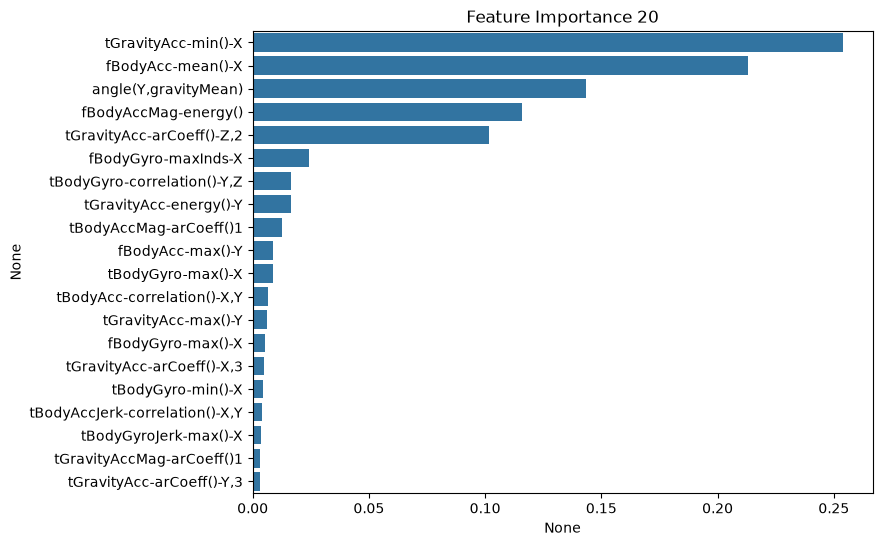

In [158]:
import seaborn as sns

ftr_importances_values = best_dt_clf.feature_importances_
ftr_importaces = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importaces.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature Importance 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()